In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = sns.load_dataset("titanic")

In [26]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [27]:
df.shape

(891, 15)

In [28]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [29]:
X = df[[ "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
y = df["survived"]

X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [30]:
X.isna().sum()

pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [31]:
X["age"] = X["age"].fillna(X["age"].median())

In [32]:
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])

In [33]:
X.isna().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [35]:
X.dtypes

pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

In [36]:
X = pd.get_dummies(X,columns=["sex", "embarked"],drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [40]:
X_train.shape, X_test.shape

((623, 8), (268, 8))

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
ss = StandardScaler()

In [44]:
X_train = ss.fit_transform(X_train)

In [45]:
X_test = ss.transform(X_test)

In [46]:
from sklearn.svm import SVC

In [47]:
svm = SVC()

In [48]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [51]:
grid_search.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [52]:
grid_search.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [53]:
grid_search.best_score_

np.float64(0.8346451612903227)

In [54]:
best_model = grid_search.best_estimator_

In [56]:
y_pred = best_model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [59]:
accuracy_score(y_test, y_pred)

0.8171641791044776

In [60]:
precision_score(y_test, y_pred)

0.8690476190476191

In [61]:
recall_score(y_test, y_pred)

0.6576576576576577

In [62]:
f1_score(y_test, y_pred)

0.7487179487179487

In [65]:
confusion_matrix(y_test, y_pred)

array([[146,  11],
       [ 38,  73]])

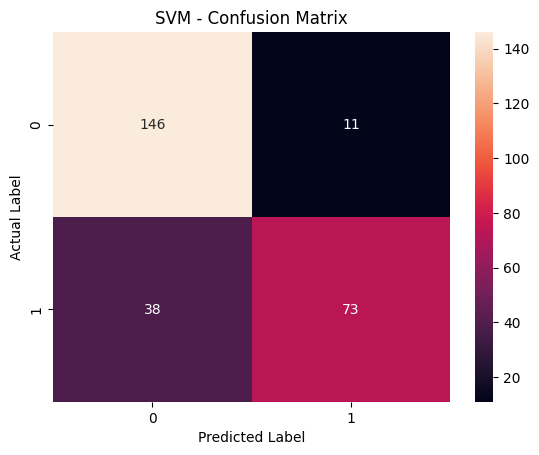

In [69]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()